# Stats Cheat Sheet — Chapters 1–3
### Descriptive Statistics, Probability & Distributions, Sampling Distributions & CLT

Reference tables + runnable examples for `scipy.stats` / `numpy` workflows.


## Chapter 1 — Descriptive Statistics & Data Exploration

| Concept | Function | What it does | Example |
|---|---|---|---|
| Mean | `np.mean(x)` / `df.mean()` | Center of the data | `np.mean(data)` |
| Median | `np.median(x)` | Middle value, robust to outliers | `np.median(data)` |
| Mode | `stats.mode(x)` | Most frequent value | `stats.mode(data)` |
| Std dev / Variance | `np.std(x, ddof=1)` / `np.var(x, ddof=1)` | Spread (use `ddof=1` for sample stats) | `np.std(data, ddof=1)` |
| Range / IQR | `np.ptp(x)`, `np.percentile(x, [25,75])` | Spread via extremes/quartiles | `np.percentile(data, [25,75])` |
| Z-scores | `stats.zscore(x)` | Standardize values | `stats.zscore(data)` |
| Correlation | `np.corrcoef(x, y)` / `stats.pearsonr(x, y)` | Linear association between two variables | `stats.pearsonr(x, y)` |
| Summary stats | `df.describe()` | Quick n/mean/std/min/max/quartiles | `df.describe()` |


In [1]:
import numpy as np
import pandas as pd
from scipy import stats

# Example dataset
data = np.array([5, 7, 3, 9, 5, 6, 8, 5, 4, 10])

print("Mean:", np.mean(data))
print("Median:", np.median(data))
print("Mode:", stats.mode(data, keepdims=True))
print("Sample Std Dev:", np.std(data, ddof=1))
print("Sample Variance:", np.var(data, ddof=1))
print("Range:", np.ptp(data))
print("IQR (Q1, Q3):", np.percentile(data, [25, 75]))
print("Z-scores:", stats.zscore(data))

pd.Series(data).describe()


Mean: 6.2
Median: 5.5
Mode: ModeResult(mode=array([5]), count=array([3]))
Sample Std Dev: 2.250925735484551
Sample Variance: 5.066666666666666
Range: 7
IQR (Q1, Q3): [5.   7.75]
Z-scores: [-0.56195149  0.37463432 -1.4985373   1.31122014 -0.56195149 -0.09365858
  0.84292723 -0.56195149 -1.03024439  1.77951304]


count    10.000000
mean      6.200000
std       2.250926
min       3.000000
25%       5.000000
50%       5.500000
75%       7.750000
max      10.000000
dtype: float64

## Chapter 2 — Probability & Discrete/Continuous Distributions

| Concept | Function | What it does | Example |
|---|---|---|---|
| Exact prob. of one discrete outcome | `<dist>.pmf(k, ...)` | P(X = k) | `binom.pmf(3, 10, 0.5)` |
| Density at a point (continuous) | `<dist>.pdf(x, ...)` | Height of density curve (not a probability itself) | `norm.pdf(0, 5.5, 3.9)` |
| Cumulative probability | `<dist>.cdf(x, ...)` | P(X ≤ x) | `norm.cdf(0, 5.5, 3.9)` |
| Upper-tail probability | `<dist>.sf(x, ...)` | P(X > x), = 1 - cdf | `norm.sf(10, 5.5, 3.9)` |
| Inverse CDF (critical values, percentiles) | `<dist>.ppf(q, ...)` | Find x for a given cumulative prob. | `norm.ppf(0.975)` |
| Simulate random draws | `<dist>.rvs(..., size=n)` | Generate sample data | `binom.rvs(10, 0.5, size=1000)` |
| Binomial (# successes in n trials) | `binom` | Coin flips, yes/no counts | `binom.pmf(k, n, p)` |
| Poisson (rare event counts) | `poisson` | Events per interval | `poisson.pmf(k, mu)` |
| Uniform, continuous | `uniform` | Equally likely over a range | `uniform.pdf(x, loc, scale)` |
| Uniform, discrete | `randint` | Equally likely integers | `randint.pmf(k, low, high)` |
| Normal | `norm` | Symmetric bell-shaped variable | `norm.cdf(x, mean, sd)` |
| Gamma (skewed, non-negative) | `gamma` | Waiting times, amounts | `gamma.pdf(x, a, scale)` |
| Expected value | `E[X] = Σx·p(x)` (manual) | Weighted mean of a distribution | `np.sum(x * p)` |
| Independence / addition rules | manual (no single function) | P(A and B) = P(A)P(B) if independent | — |


In [2]:
from scipy.stats import binom, poisson, uniform, randint, norm, gamma

# Binomial: P(exactly 3 heads in 10 flips)
print("binom.pmf(3,10,0.5):", binom.pmf(3, 10, 0.5))

# Normal: P(X <= 0) for mean=5.5, sd=3.9
print("norm.cdf(0, 5.5, 3.9):", norm.cdf(0, 5.5, 3.9))

# Normal: P(X > 10)
print("norm.sf(10, 5.5, 3.9):", norm.sf(10, 5.5, 3.9))

# Inverse CDF: 97.5th percentile of standard normal (95% CI z-value)
print("norm.ppf(0.975):", norm.ppf(0.975))

# Simulate 1000 binomial draws
sim = binom.rvs(10, 0.5, size=1000)
print("Simulated mean:", sim.mean())

# Expected value from a discrete distribution manually
k = np.arange(0, 11)
p = binom.pmf(k, 10, 0.5)
print("E[X] via weighted sum:", np.sum(k * p))


binom.pmf(3,10,0.5): 0.1171875
norm.cdf(0, 5.5, 3.9): 0.07923199226950461
norm.sf(10, 5.5, 3.9): 0.12428162410859106
norm.ppf(0.975): 1.959963984540054
Simulated mean: 4.994
E[X] via weighted sum: 4.999999999999999


## Chapter 3 — Sampling Distributions & the Central Limit Theorem

| Concept | Function | What it does | Example |
|---|---|---|---|
| Exact sampling distribution of p̂ | `binom.pmf(k, n, p)` then `k/n` | Enumerate all possible sample proportions | see coin-flip problem |
| Simulated sampling distribution | `dist.rvs(..., size=(B, n)).mean(axis=1)` | Monte Carlo approx. of a statistic's distribution | `rng.uniform(0,10,(B,n)).mean(axis=1)` |
| Standard error (formula, proportion) | `np.sqrt(p*(1-p)/n)` | SE of sample proportion | manual |
| Standard error (simulated) | `samples.std(ddof=1)` | SE estimated from simulated sampling dist. | `means.std(ddof=1)` |
| SE of the mean from one sample | `spread / np.sqrt(n)` | Plug-in SE using sample/pop SD | `3.9/np.sqrt(10000)` |
| z critical value (large n, CLT applies) | `norm.ppf(1 - alpha/2)` | Multiplier for CI when n large | `norm.ppf(0.975)` → 1.96 |
| t critical value (small n or unknown pop SD) | `t.ppf(1 - alpha/2, df=n-1)` | Multiplier for CI, heavier tails | `t.ppf(0.975, 9999)` |
| Confidence interval (formal) | `center ± t_crit * se` | Interval likely to contain the parameter | see below |
| Normal approx. to binomial | check `n*p≥10` and `n*(1-p)≥10`, then `norm.cdf` | Approximate binomial with normal when conditions hold | `norm.cdf(x, n*p, sqrt(n*p*(1-p)))` |
| Law of Large Numbers vs. CLT | conceptual, no function | LLN: estimate → true value as n→∞. CLT: shape of sampling dist. → normal as n→∞ | — |
| Bootstrapping | resample your own data | Simulate sampling distribution from observed data (no assumed population param) | `np.random.choice(sample, len(sample), replace=True)` |


In [3]:
from scipy.stats import t
import numpy as np
from numpy.random import default_rng

rng = default_rng(42)

# --- Number of good friends example ---
center = 5.5
spread = 3.9
n = 10000

p_below_zero = norm.cdf(0, center, spread)
se = spread / np.sqrt(n)

multiplier = 1.96                       # justified: n=10000 -> CLT applies -> z ~ 1.96 for 95% CI
rough_interval = (center - multiplier * se, center + multiplier * se)

t_crit = t.ppf(0.975, n - 1)            # 0.975 = upper cutoff for 95% two-sided CI
formal_interval = (center - t_crit * se, center + t_crit * se)

print("P(Y<0) under normal assumption:", p_below_zero)
print("SE:", se)
print("Rough (z) interval:", rough_interval)
print("Formal (t) interval:", formal_interval)


P(Y<0) under normal assumption: 0.07923199226950461
SE: 0.039
Rough (z) interval: (np.float64(5.42356), np.float64(5.57644))
Formal (t) interval: (np.float64(5.423552150718767), np.float64(5.576447849281233))


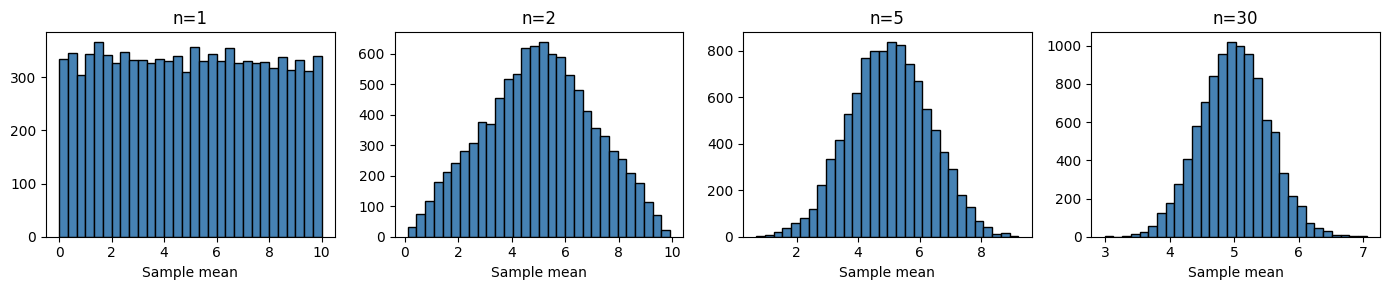

In [4]:
# --- CLT demo: sampling distribution of the mean from a uniform population ---
import matplotlib.pyplot as plt

low, high = 0, 10
B = 10000
n_values = [1, 2, 5, 30]

fig, axes = plt.subplots(1, len(n_values), figsize=(14, 3))
for ax, n_ in zip(axes, n_values):
    x = rng.uniform(low, high, size=(B, n_))
    means = x.mean(axis=1)
    ax.hist(means, bins=30, color="steelblue", edgecolor="black")
    ax.set_title(f"n={n_}")
    ax.set_xlabel("Sample mean")
plt.tight_layout()
plt.show()


## Mini Action Plan — How to use this cheat sheet

1. First ask: is this about **one value's probability** (→ pmf/pdf), **a range** (→ cdf/sf), or **a critical value** (→ ppf)?
2. Then ask: discrete or continuous, and which shape (binomial / uniform / normal / gamma)?
3. If it's about a **statistic across repeated samples** (not raw data) — that's Ch.3 territory: sampling distribution, SE, CLT.
4. Large n (rule of thumb ≥30, or specific `np≥10` / `n(1-p)≥10` for proportions) → normal approx. justified, use z.
5. Small n or unknown population SD → use t, not z.
6. When unsure whether to simulate or enumerate exactly: if you can enumerate exactly (like coin flips), do that — simulate only when exact enumeration isn't feasible or the assignment explicitly asks for it.
